# Object Detection — Stage 1 (Localisation)

Trains `ObjectDetectorResNet` to predict up to `MAX_OBJECTS` bounding boxes per image.  
Each predicted slot is `[x, y, w, h, conf]`; confidence is a raw logit trained with BCE.

**Pipeline:**  
`get_detection_loaders` → `ObjectDetectorResNet` → `DetectionLoss` → `fit(task_type='detection')`

In [1]:
import sys
sys.path.insert(0, '..')

import torch

from utils.dataset   import get_detection_loaders
from utils.trainer   import fit, evaluate_detection_sweep, evaluate_detection
from utils.callbacks import ModelCheckpoint
from utils.losses    import DetectionLoss
from models import get_detector

# ── Config ────────────────────────────────────────────────────────────────────
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ROOT_DIR    = '../data'
BATCH_SIZE  = 198
EPOCHS      = 60
MAX_OBJECTS = 24      # must match generator max_objects
CONF_THRESH = 0.5     # sigmoid threshold at inference
LAMBDA_CONF = 1.0     # weight on confidence loss

print(f'Device : {DEVICE}')
print(f'PyTorch: {torch.__version__}')

Device : cuda
PyTorch: 2.11.0+cu130


## 1 · Data Loaders

In [2]:
train_loader, val_loader, test_loader = get_detection_loaders(
    batch_size = BATCH_SIZE,
    test=True,
)

# ── Sanity check ──────────────────────────────────────────────────────────────
batch = next(iter(train_loader))
imgs, boxes, labels, mask = batch

print(f'Image batch shape : {imgs.shape}')
print(f'GT boxes shape    : {boxes.shape}')
print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

Image batch shape : torch.Size([198, 1, 224, 224])
GT boxes shape    : torch.Size([198, 15, 4])
Train batches: 1213 | Val batches: 76


## 2 · Model

In [3]:
model = get_detector(size="m", max_objects=MAX_OBJECTS).to(DEVICE)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

# ── Forward smoke-test ────────────────────────────────────────────────────────
with torch.no_grad():
    out = model(imgs.to(DEVICE))
print(f'Output shape: {out.shape}')  # (B, MAX_OBJECTS, 5)  — [x, y, w, h, conf]

Parameters: 8,836,856
Output shape: torch.Size([198, 24, 5])


## 3 · Loss — Huber + BCE confidence

`DetectionLoss` lives in `utils/losses.py`:
- Greedy IoU match → each GT box assigned to the best predicted slot
- **Box loss**: `HuberLoss` on matched pairs
- **Conf loss**: `BCEWithLogitsLoss` — matched slots → 1.0, background → 0.0

In [4]:
criterion = DetectionLoss(lambda_conf=LAMBDA_CONF, delta=1.0, use_pos_weight=True)
print('DetectionLoss ready.')

# ── Quick loss smoke-test ─────────────────────────────────────────────────────
boxes_v = boxes.to(DEVICE)
mask_v = mask.to(DEVICE)

with torch.no_grad():
    dummy_out   = model(imgs.to(DEVICE))
    loss_val    = criterion(dummy_out, boxes_v, mask_v)
print(f'Smoke-test loss: {loss_val.item():.4f}')  # should be finite

DetectionLoss ready.
Smoke-test loss: 60.2485


## 4 · Optimiser & Scheduler

In [5]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr           = 1e-3,
    weight_decay = 1e-4,
)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr          = 1e-3,
    steps_per_epoch = len(train_loader),
    epochs          = EPOCHS,
)

NAME = "detector_medium"
checkpoint = ModelCheckpoint(
    model, verbose=False,
    checkpoint_path=f"../checkpoint/{NAME}_latest.pth",
    best_model_path=f"../checkpoint/{NAME}_best.pth",
    mode='max'   # maximise val_iou
)

scaler = torch.amp.GradScaler('cuda')

print(f'Optimizer : {type(optimizer).__name__}')
print(f'Scheduler : {type(scheduler).__name__}')

Optimizer : AdamW
Scheduler : OneCycleLR


## 5 · Train

In [6]:
history, logger = fit(
    model       = model,
    trainloader = train_loader,
    valloader   = val_loader,
    criterion   = criterion,
    optimizer   = optimizer,
    device      = DEVICE,
    epochs      = EPOCHS,
    task_type   = 'detection',
    scheduler   = scheduler,
    scaler      = scaler,
    checkpoint  = checkpoint,
    step_scheduler_per_batch = True,
    verbose     = True,
    log         = True,
    model_label = NAME,
    resume=True
)

Training with bf16 autocast | Task: detection | Epochs: 60
[RunLogger] ▶  Run 'detector_medium_20260721_081930' started — saving to 'C:\OD-From-Scratch\logs\ObjectDetectorResNet\detector_medium_20260721_081930.json'
Resuming training from epoch 38
Batch  1 | match=1.00 hungar=1.8ms data=742.9ms pad=1.2ms forward=200.6ms loss=8.4ms backward=246.6ms step=163.5ms
Batch  2 | match=1.00 hungar=2.2ms data=0.2ms pad=0.8ms forward=31.0ms loss=7.1ms backward=66.3ms step=4.3ms
Batch  3 | match=1.00 hungar=2.1ms data=0.2ms pad=0.8ms forward=30.9ms loss=5.8ms backward=67.1ms step=4.3ms
Batch  4 | match=1.00 hungar=2.2ms data=0.2ms pad=0.8ms forward=31.0ms loss=6.2ms backward=66.6ms step=4.6ms
Batch  5 | match=1.00 hungar=2.1ms data=0.2ms pad=0.8ms forward=30.9ms loss=6.0ms backward=65.7ms step=7.8ms
  --> Epoch Average Match Ratio: 1.0000
Train: 131.1s | Val: 45.4s
  --> PR: 0.875 | Rec: 0.967 | F1: 0.919 | TP: 115796 FP: 16583 FN: 3954
[RunLogger] Epoch  39 | train_loss=0.7379  val_loss=0.8115  v

## 6 · Training Curves

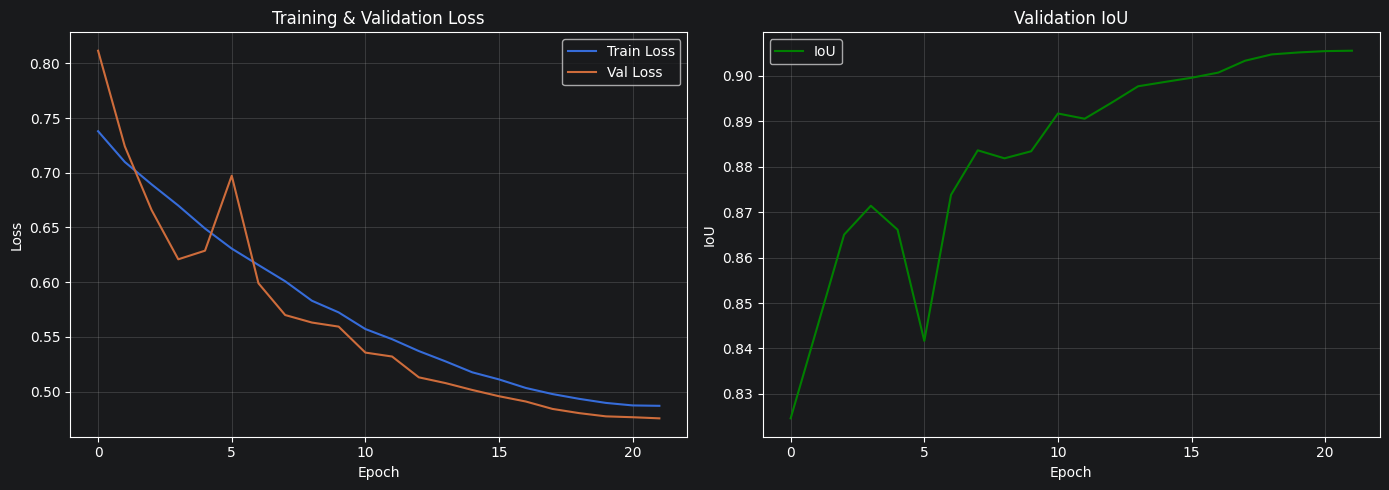

In [7]:
from utils.visualizer import Visualizer

Visualizer.visualize_training_curves(history['train_loss'], history['val_loss'], history['val_iou'], metric_label='IoU')

## 7 · Prediction Visualisation

- **Green** boxes = ground truth
- **Red** (dashed) boxes = model predictions with `conf > CONF_THRESH`

In [8]:
# -- Evaluate on Test Set (greedy IoU at conf=0.5) --
from utils.trainer import evaluate_detection
checkpoint.restore_best_weights()
metrics = evaluate_detection(model, test_loader, criterion, DEVICE)
print(f"Test loss : {metrics['val_loss']:.4f}")
print(f"Test IoU  : {metrics['val_iou']:.4f}")


Test loss : 0.5197
Test IoU  : 0.8936


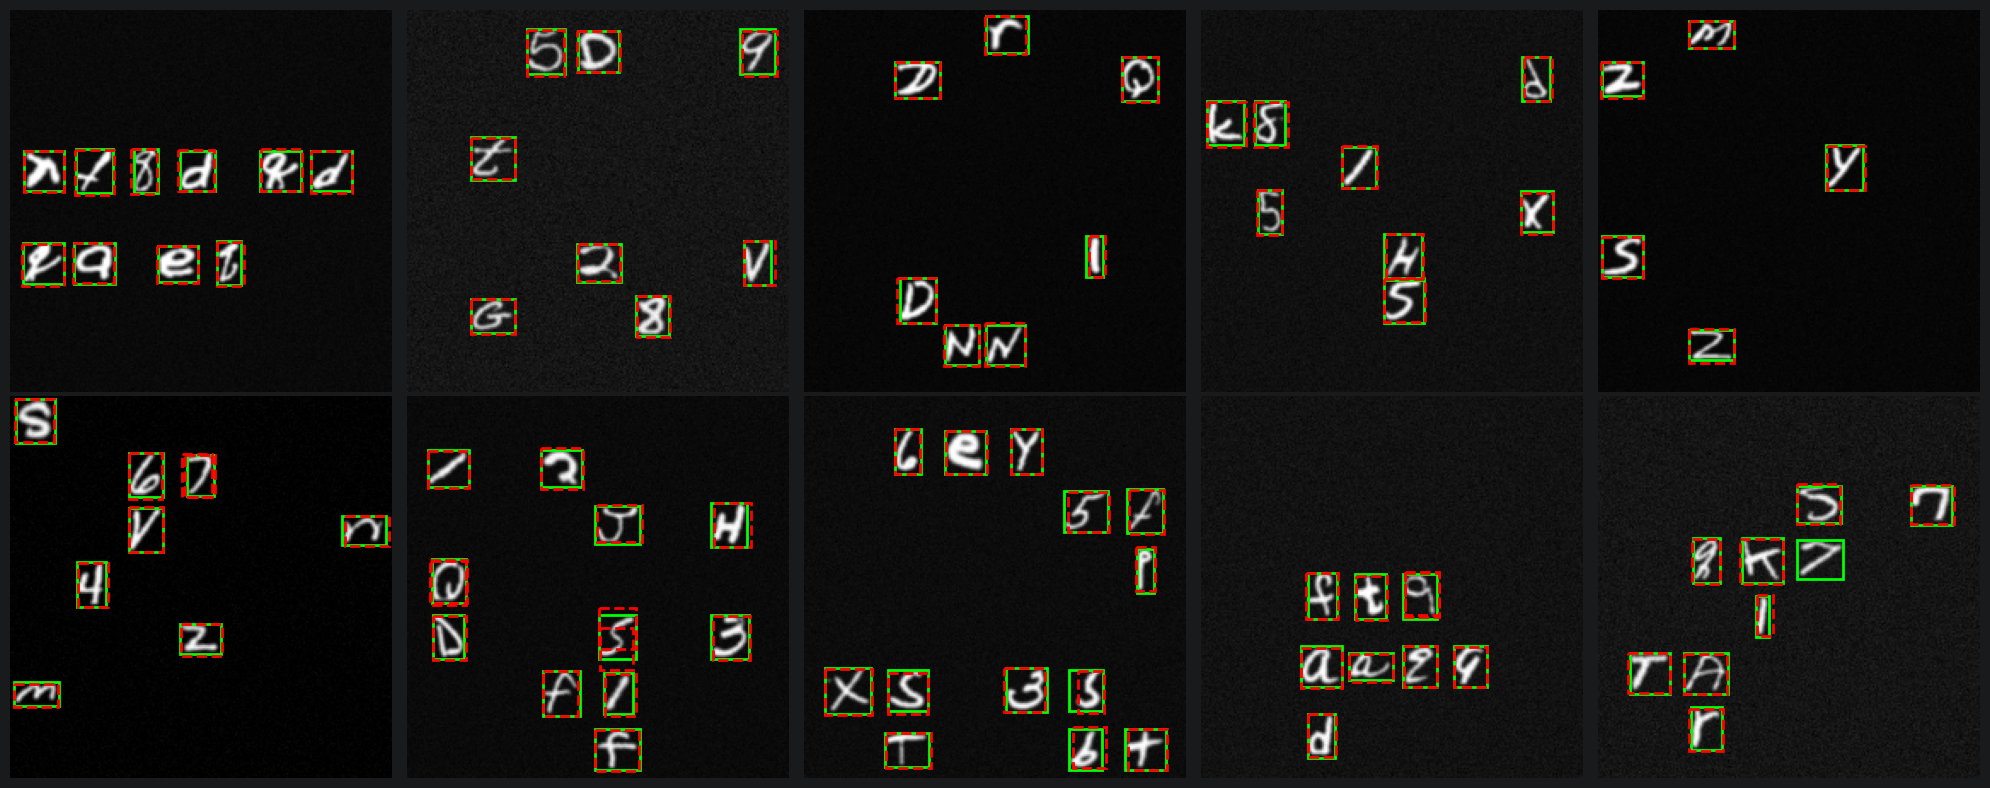

In [9]:
test_batch = next(iter(test_loader))
imgs_t, boxes_t, labels_t, mask_t = test_batch
with torch.no_grad():
    preds_t = model(imgs_t.to(DEVICE)).cpu()
Visualizer.visualize_multi_detection_batch(
    imgs_v=imgs_t,
    preds=preds_t,
    boxes_v=boxes_t,
    mask_v=mask_t,
    conf_thresh=CONF_THRESH
)

## 8 · Test-Set Confidence Threshold Sweep

Run `evaluate_detection_sweep` on the held-out **test set** to see the full P/R/F1 trade-off
across confidence thresholds. The model runs **once** and all thresholds are swept in pure NumPy,
so the sweep is fast.

Results can be saved into the run JSON under `test_results.threshold_sweep` via
`logger.log_test_results()`.

In [10]:
sweep_results = evaluate_detection_sweep(
    model, test_loader, DEVICE,
    iou_threshold=0.5,
    print_table=True,
)

if logger is not None:
    logger.log_test_results(sweep_results, iou_threshold=0.5)



  Conf       P       R      F1       TP       FP       FN
--------------------------------------------------------
  0.20  0.8121  0.9836  0.8897   353428    81761     5895
  0.30  0.8443  0.9824  0.9081   353016    65125     6307
  0.40  0.8758  0.9802  0.9251   352209    49931     7114
  0.50  0.9098  0.9757  0.9416   350604    34770     8719
  0.60  0.9470  0.9641  0.9555   346439    19401    12884
  0.70  0.9753  0.9323  0.9533   335009     8498    24314
  0.80  0.9856  0.8770  0.9281   315122     4589    44201

[RunLogger] Test sweep (threshold_sweep) — IoU threshold: 0.5
  Conf       P       R      F1
--------------------------------
  0.20  0.8121  0.9836  0.8897
  0.30  0.8443  0.9824  0.9081
  0.40  0.8758  0.9802  0.9251
  0.50  0.9098  0.9757  0.9416
  0.60  0.9470  0.9641  0.9555
  0.70  0.9753  0.9323  0.9533
  0.80  0.9856  0.8770  0.9281
